
# Creating Synthetic 3D Image

## Description
This notebook focuses on **creating synthetic 3D images** (e.g., a 3d voxel space with a custom arrangement of spheres) for use in segmentation pipeline experiments. It serves as the first step in the overall workflow.

## Part of Pipeline
- **Previous Step**: N/A (This is the first step)
- **Next Step**: Thresholding the image

## Requirements
- Python 3.11
- Libraries:
  - matplotlib
  - numpy

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

# Functions for visualisations
from src.visualisation import (
    plot_2d_slice_with_values,
    plot_panels,
)

# Integrate figures into notebook
%matplotlib notebook
%matplotlib inline
plt.close()


### Step 1 — Create an Empty 3D Volume

We start by allocating a cubic **3D array** of zeros with `dtype=np.uint8`.
This represents a blank image volume into which we’ll “draw” shapes.

In [2]:
# --- Volume size definition (feel free to adjust) ---
volume_size = 16           # cubic volume: (Z, Y, X)

image3d = np.zeros((volume_size, volume_size, volume_size), dtype=np.uint8)

print("Volume summary:")
print("  shape:", image3d.shape)
print("  dtype:", image3d.dtype)
print("  min/max:", image3d.min(), image3d.max())


Volume summary:
  shape: (16, 16, 16)
  dtype: uint8
  min/max: 0 0


### Step 2 — Adding Spheres to the 3D Volume

Now that we have an empty 3D volume, let’s place one or more spheres inside it.
This simulates objects in a synthetic dataset, which we’ll later use for segmentation.

To do this, we first generate coordinate grids using `np.indices(volume_shape)`.
These grids give us the `(z, y, x)` position of every voxel in the volume.

Next, we apply the **sphere equation** to decide which voxels belong inside the sphere:
$(z - c_z)^2 + (y - c_y)^2 + (x - c_x)^2 \le r^2$

This produces a **boolean mask**:
- `True` → voxel is inside the sphere
- `False` → voxel is outside

Finally, we’ll use this mask to assign intensity values to the sphere voxels.


In [3]:
# Define a function to add a sphere to a 3d volume
def create_sphere(volume_shape, centre, radius, intensity):
    """Create a 3D uint8 array containing a single solid sphere at given centre/radius.
    Returns a *new* array; does not modify an input image.
    """
    # Create coordinate grids for the entire volume
    z, y, x = np.ogrid[: volume_shape[0], : volume_shape[1], : volume_shape[2]]

    # Calculate Euclidean distance from centre for all voxels
    cz, cy, cx = centre
    distance_from_centre = np.sqrt((z - cz) ** 2 + (y - cy) ** 2 + (x - cx) ** 2)

    # Create mask: voxels within radius belong to sphere
    sphere_mask = distance_from_centre <= radius

    return (sphere_mask * intensity).astype(np.uint8)

# --- 1. Sphere parameter definition ---
centre_s1 = (8, 9, 8)      # (cz, cy, cx)
radius_s1 = 3                 # in voxels
intensity_s1 = 180            # uint8 grayscale

# Add the sphere by calling the function
sphere1 = create_sphere(image3d.shape, centre_s1, radius_s1, intensity_s1)
# Merge with max (preserves the higher intensity at overlaps)
image3d = np.maximum(image3d, sphere1)

# --- 2. Sphere parameter definition ---
centre_s2 = (7, 5, 4)      # (cz, cy, cx)
radius_s2 = 4                 # in voxels
intensity_s2 = 190           # uint8 grayscale

# Add the sphere by calling the function
sphere2 = create_sphere(image3d.shape, centre_s2, radius_s2, intensity_s2)
# Merge with max again
image3d = np.maximum(image3d, sphere2)

### Step 3 (Optional) — Adding random image noise

Most physical image acquisition techniques have an inherent noise profile. We can mimic this by adding a artificial random noise to our volume with discrete background ("0") and foreground (sphere intensity).

We split the image in tow parts:
1. Background: This is currently set to "0", we add Gausaian noise centered at 25, and a confidence interval [0,30].
2. Foreground: These are the spheres, we add Gaussian noise centered at the respective intensities, and with a confidence interval of [intensity-5,intensity+5].


In [4]:
# Parameters
sigma_nonzero = 2.5          # ±5 range for non-zero voxels
sigma_background = 5          # ~95% of Gaussian in 0-20 for background
mean_background = 25

# Mask for zeros and non-zeros
mask_zero = image3d == 0
mask_nonzero = ~mask_zero

# Background voxels: Gaussian around 10
bg_noise = np.random.normal(loc=mean_background, scale=sigma_background, size=mask_zero.sum())
image3d[mask_zero] = np.round(bg_noise).astype(np.int32)

# Non-zero voxels: Gaussian around original value
nonzero_noise = np.random.normal(loc=0, scale=sigma_nonzero, size=mask_nonzero.sum())
image3d[mask_nonzero] = np.round(image3d[mask_nonzero] + nonzero_noise).astype(np.int32)

# Clip to valid range (e.g., 0–255), to ensure dtype conformity
image_int = np.clip(image3d, 0, 255)

# Write synthetic image out
np.save(file='../src/data/synthetic_image.npy', arr=image3d)

### Visualizing the Synthetic 3D Image

To confirm that our spheres were added correctly, we’ll display a **single slice** of the 3D volume.
This gives us a quick 2D view of the structure inside the synthetic image.

The umbrella function **plot_panels** and function to create the 2-d slice **plot_2d_slice_with_values** are defined in the **visualisation** script. A second slice can be visualised (for example neighbouring) by extending the argument lists given to the umbrella function.

**Exercise 1:** Visualize a different slice (e.g., `slice_index = 3` or `slice_index = image3d.shape[0] - 1`).
How does the appearance of the spheres change as you move through the volume?

**Exercise 2:** Display three slices: one near the top, one in the middle, and one near the bottom.
Tip: Use `plot_panels(n=3, data_list=[image3d]*3, plot_kwargs_list=[{"slice_index": i} for i in [2, 7, 12]])`.

**Ecercise 3:** Add spheres and change the overlap rule from `np.maximum` to `overwrite` when adding spheres. Try to create different overlap scenario.
Visualize the slice and explain what happens in overlapping regions.

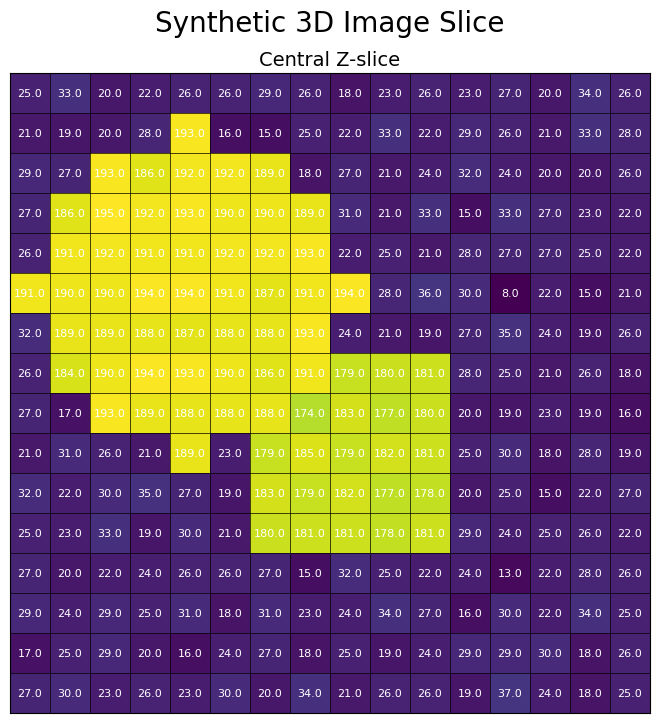

In [5]:
# Visualize a single 2D slice of the synthetic 3D image using plot_panels
plot_slice_index = 7 # Slice index to be visualised
plot_panels(
    n=1,
    data_list=[image3d],
    plot_func=plot_2d_slice_with_values,
    plot_kwargs_list=[{"slice_index": plot_slice_index}],
    title="Synthetic 3D Image Slice",
    subtitles=["Central Z-slice"]
)